In [1]:
# Setup
from mlwpy import *
%matplotlib inline
diabetes = datasets.load_diabetes()
tts = skms.train_test_split(diabetes.data,
diabetes.target,
test_size=.25,
random_state=42)
(diabetes_train_ftrs, diabetes_test_ftrs,
diabetes_train_tgt, diabetes_test_tgt) = tts

In [2]:
baseline = dummy.DummyRegressor(strategy='median')

In [3]:
strategies = ['constant', 'quantile', 'mean', 'median']
baseline_args = [{"strategy": s} for s in strategies]
baseline_args[0]['constant'] = 50.0
baseline_args[1]['quantile'] = 0.75

def do_one(**args):
    baseline = dummy.DummyRegressor(**args)
    baseline.fit(diabetes_train_ftrs, diabetes_train_tgt)
    base_preds = baseline.predict(diabetes_test_ftrs)
    return metrics.mean_squared_error(base_preds, diabetes_test_tgt)

mses = [do_one(**bla) for bla in baseline_args]
display(pd.DataFrame({'mse': mses}, index=strategies))


,mse
constant,"14,657.6847"
quantile,"10,216.3874"
mean,"5,607.1979"
median,"5,542.2252"


In [4]:
def rms_error(actual, predicted):
    ' root-mean-squared-error function '
    mse = metrics.mean_squared_error(actual, predicted)
    return np.sqrt(mse)

def neg_rmse_score(actual, predicted):
    ' rmse based score function '
    return -rms_error(actual, predicted)

def neg_rmse_scorer(mod, ftrs, tgt_actual):
    ' rmse scorer suitable for scoring arg '
    tgt_pred = mod.predict(ftrs)
    return neg_rmse_score(tgt_actual, tgt_pred)

knn = neighbors.KNeighborsRegressor(n_neighbors=3)
skms.cross_val_score(
    knn,
    diabetes.data, diabetes.target,
    cv=skms.KFold(5, shuffle=True),
    scoring=neg_rmse_scorer
)


array([-58.0034, -64.9886, -63.1431, -61.8124, -57.6243])

In [5]:
lr = linear_model.LinearRegression()
# help(lr.score) # for full output
print(lr.score.__doc__.splitlines()[0])

Return the coefficient of determination of the prediction.


In [6]:
our_preds = np.array([1, 2, 3])
mean_preds = np.array([2, 2, 2])
actual = np.array([2, 3, 4])
sse_ours = np.sum(( our_preds - actual)**2)
sse_mean = np.sum((mean_preds - actual)**2)

In [7]:
r_2 = 1 - (sse_ours / sse_mean)
print("manual r2:{:5.2f}".format(r_2))

manual r2: 0.40


In [8]:
baseline = dummy.DummyRegressor(strategy='mean')
baseline.fit(diabetes_train_ftrs, diabetes_train_tgt)
base_preds = baseline.predict(diabetes_test_ftrs)
# r2 is not symmetric because true values have priority
# and are used to compute target mean
base_r2_sklearn = metrics.r2_score(diabetes_test_tgt, base_preds)
print(base_r2_sklearn)

-0.014016723490579253


In [9]:
# sklearn-train-mean to predict test tgts
base_errors = base_preds - diabetes_test_tgt
sse_base_preds = np.dot(base_errors, base_errors)
# train-mean to predict test targets
train_mean_errors = np.mean(diabetes_train_tgt) - diabetes_test_tgt
sse_mean_train = np.dot(train_mean_errors, train_mean_errors)
# test-mean to predict test targets (Danger Will Robinson!)
test_mean_errors = np.mean(diabetes_test_tgt) - diabetes_test_tgt
sse_mean_test = np.dot(test_mean_errors, test_mean_errors)
print("sklearn train-mean model SSE(on test):", sse_base_preds)
print(" manual train-mean model SSE(on test):", sse_mean_train)
print(" manual test-mean model SSE(on test):", sse_mean_test)

sklearn train-mean model SSE(on test): 622398.970317905
 manual train-mean model SSE(on test): 622398.970317905
 manual test-mean model SSE(on test): 613795.5675675675


In [10]:
1 - (sse_base_preds / sse_mean_test)

np.float64(-0.014016723490578809)

In [11]:
print(base_r2_sklearn)
print(1 - (sse_base_preds / sse_mean_test))

-0.014016723490579253
-0.014016723490578809


In [12]:
testbase = dummy.DummyRegressor(strategy='mean')
testbase.fit(diabetes_test_ftrs, diabetes_test_tgt)
testbase_preds = testbase.predict(diabetes_test_ftrs)
testbase_mse = metrics.mean_squared_error(testbase_preds, diabetes_test_tgt)

models = [
    neighbors.KNeighborsRegressor(n_neighbors=3),
    linear_model.LinearRegression()
]

results = co.defaultdict(dict)

for m in models:
    preds = (m.fit(diabetes_train_ftrs, diabetes_train_tgt)
               .predict(diabetes_test_ftrs))
    mse = metrics.mean_squared_error(preds, diabetes_test_tgt)
    r2 = metrics.r2_score(diabetes_test_tgt, preds)
    results[get_model_name(m)]['R^2'] = r2
    results[get_model_name(m)]['MSE'] = mse

print(testbase_mse)

df = pd.DataFrame(results).T
df['Norm_MSE'] = df['MSE'] / testbase_mse
df['1-R^2'] = 1 - df['R^2']
display(df)


5529.689797906013


,R^2,MSE,Norm_MSE,1-R^2
KNeighborsRegressor,0.3722,"3,471.4194",0.6278,0.6278
LinearRegression,0.4849,"2,848.3107",0.5151,0.5151


In [13]:
ape_df = pd.DataFrame({'predicted' : [4, 2, 9],
'actual' : [3, 5, 7]})
ape_df['error'] = ape_df['predicted'] - ape_df['actual']
ape_df.index.name = 'example'
display(ape_df)

,predicted,actual,error
example,,,
0,4,3,1
1,2,5,-3
2,9,7,2


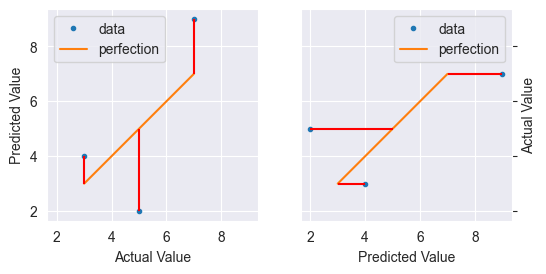

In [14]:
def regression_errors(figsize, predicted, actual, errors='all'):
    ''' figsize -> subplots;
        predicted/actual data -> columns in a DataFrame
        errors -> "all" or sequence of indices '''
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharex=True, sharey=True)
    df = pd.DataFrame({'actual': actual, 'predicted': predicted})

    for ax, (x, y) in zip(axes, it.permutations(['actual', 'predicted'])):
        ax.plot(df[x], df[y], '.', label='data')
        ax.plot(df['actual'], df['actual'], '-', label='perfection')
        ax.legend()
        ax.set_xlabel('{} Value'.format(x.capitalize()))
        ax.set_ylabel('{} Value'.format(y.capitalize()))
        ax.set_aspect('equal')

    axes[1].yaxis.tick_right()
    axes[1].yaxis.set_label_position("right")

    if errors == 'all':
        errors = range(len(df))
    if errors:
        acts = df.actual.iloc[errors]
        preds = df.predicted.iloc[errors]
        axes[0].vlines(acts, preds, acts, 'r')
        axes[1].hlines(acts, preds, acts, 'r')

regression_errors((6, 3), ape_df.predicted, ape_df.actual)


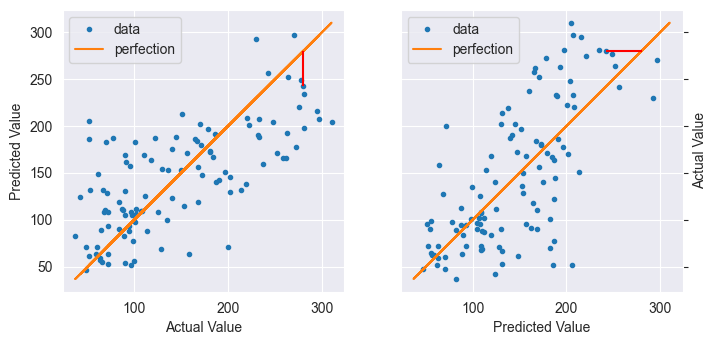

In [15]:
lr = linear_model.LinearRegression()
preds = (lr.fit(diabetes_train_ftrs, diabetes_train_tgt)
.predict(diabetes_test_ftrs))
regression_errors((8, 4), preds, diabetes_test_tgt, errors=[-20])

In [16]:
ape_df = pd.DataFrame({
    'predicted': [4, 2, 9],
    'actual': [3, 5, 7]
})
ape_df['error'] = ape_df['predicted'] - ape_df['actual']
ape_df['resid'] = ape_df['actual'] - ape_df['predicted']
ape_df.index.name = 'example'
display(ape_df)


,predicted,actual,error,resid
example,,,,
0,4,3,1,-1
1,2,5,-3,3
2,9,7,2,-2


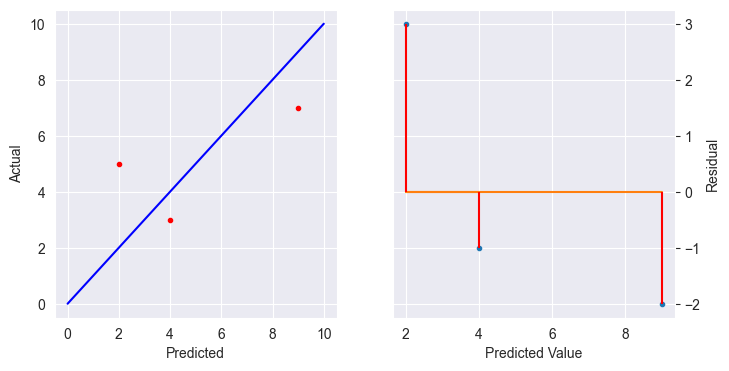

In [17]:
def regression_residuals(ax, predicted, actual, show_errors=None, right=False):
    ''' figsize -> subplots;
        predicted/actual data -> columns of a DataFrame
        errors -> "all" or sequence of indices '''
    df = pd.DataFrame({'actual': actual, 'predicted': predicted})
    df['error'] = df.actual - df.predicted

    ax.plot(df.predicted, df.error, '.')
    ax.plot(df.predicted, np.zeros_like(predicted), '-')

    if right:
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")

    ax.set_xlabel('Predicted Value')
    ax.set_ylabel('Residual')

    if show_errors == 'all':
        show_errors = range(len(df))
    if show_errors:
        preds = df.predicted.iloc[show_errors]
        errors = df.error.iloc[show_errors]
        ax.vlines(preds, 0, errors, 'r')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.plot(ape_df.predicted, ape_df.actual, 'r.', [0, 10], [0, 10], 'b-')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
regression_residuals(ax2, ape_df.predicted, ape_df.actual, 'all', right=True)


Text(0.5, 1.0, 'k-NN-Regressor Residuals')

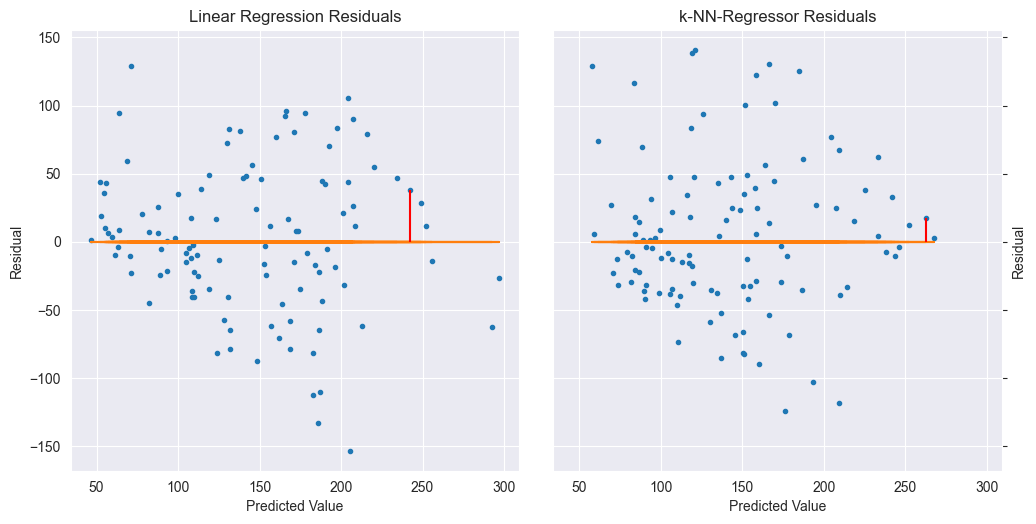

In [18]:
lr = linear_model.LinearRegression()
knn = neighbors.KNeighborsRegressor()
models = [lr, knn]

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
fig.tight_layout()

for model, ax, on_right in zip(models, axes, [False, True]):
    preds = (model.fit(diabetes_train_ftrs, diabetes_train_tgt)
                  .predict(diabetes_test_ftrs))
    regression_residuals(ax, preds, diabetes_test_tgt, [-20], on_right)

axes[0].set_title('Linear Regression Residuals')
axes[1].set_title('k-NN-Regressor Residuals')


In [19]:
print(diabetes_test_tgt[-20])

280.0


,x,std-ized
mean,2.5000,0.0000
std,4.6706,1.0000


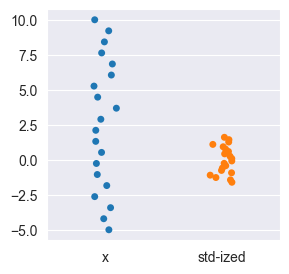

In [20]:
xs = np.linspace(-5, 10, 20)
df = pd.DataFrame(xs, columns=['x'])
df['std-ized'] = (df.x - df.x.mean()) / df.x.std()

fig, ax = plt.subplots(1, 1, figsize=(3, 3))
sns.stripplot(data=df, ax=ax)

display(df.describe().loc[['mean', 'std']])


In [21]:
# 2 1D standardizations
xs = np.linspace(-5, 10, 20)
ys = 3*xs + 2 + np.random.uniform(20, 40, 20)
df = pd.DataFrame({'x':xs, 'y':ys})
df_std_ized = (df - df.mean()) / df.std()
display(df_std_ized.describe().loc[['mean', 'std']])

,x,y
mean,0.0000,-0.0000
std,1.0000,1.0000


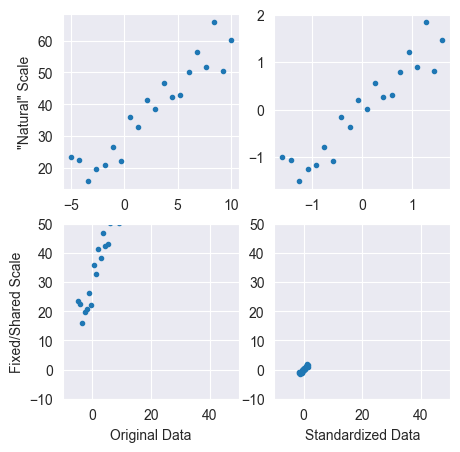

In [22]:
fig, ax = plt.subplots(2, 2, figsize=(5, 5))
ax[0,0].plot(df.x, df.y, '.')
ax[0,1].plot(df_std_ized.x, df_std_ized.y, '.')
ax[0,0].set_ylabel('"Natural" Scale')
ax[1,0].plot(df.x, df.y, '.')
ax[1,1].plot(df_std_ized.x, df_std_ized.y, '.')
ax[1,0].axis([-10, 50, -10, 50])
ax[1,1].axis([-10, 50, -10, 50])
ax[1,0].set_ylabel('Fixed/Shared Scale')
ax[1,0].set_xlabel('Original Data')
ax[1,1].set_xlabel('Standardized Data');

In [23]:
train_xs, test_xs = skms.train_test_split(xs.reshape(-1, 1), test_size=.5)
scaler = skpre.StandardScaler()
scaler.fit(train_xs).transform(test_xs)

array([[ 0.5726],
       [ 0.9197],
       [ 1.9608],
       [ 0.7462],
       [ 1.7873],
       [-0.295 ],
       [ 1.6138],
       [ 1.4403],
       [-0.1215],
       [ 1.0932]])

In [24]:
(train_xs, test_xs,
train_ys, test_ys)= skms.train_test_split(xs.reshape(-1, 1),
ys.reshape(-1, 1),
test_size=.5)
scaler = skpre.StandardScaler()
lr = linear_model.LinearRegression()
std_lr_pipe = pipeline.make_pipeline(scaler, lr)
std_lr_pipe.fit(train_xs, train_ys).predict(test_xs)

array([[17.0989],
       [29.4954],
       [41.8919],
       [36.9333],
       [61.7263],
       [24.5368],
       [31.9747],
       [49.3298],
       [51.8091],
       [59.247 ]])

In [27]:
student_df = pd.read_csv('data/portugese_student_numeric.csv')
display(student_df[['absences']].describe().T)


,count,mean,std,min,25%,50%,75%,max
absences,649.0000,3.6595,4.6408,0.0000,0.0000,2.0000,6.0000,32.0000


In [28]:
student_ftrs = student_df[student_df.columns[:-1]]
student_tgt = student_df['G3']

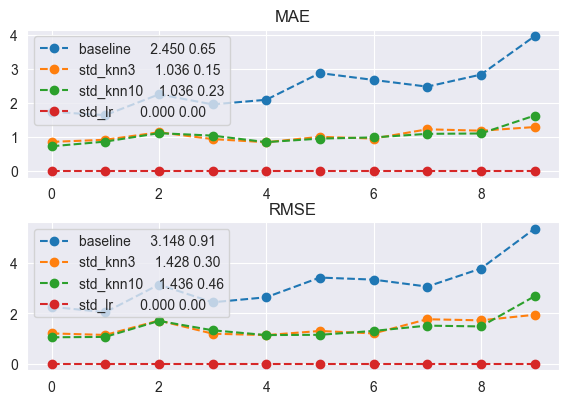

In [30]:
scaler = skpre.StandardScaler()
lr = linear_model.LinearRegression()
knn_3 = neighbors.KNeighborsRegressor(n_neighbors=3)
knn_10 = neighbors.KNeighborsRegressor(n_neighbors=10)

std_lr_pipe = pipeline.make_pipeline(scaler, lr)
std_knn3_pipe = pipeline.make_pipeline(scaler, knn_3)
std_knn10_pipe = pipeline.make_pipeline(scaler, knn_10)

regressors = {
    'baseline': dummy.DummyRegressor(strategy='mean'),
    'std_knn3': std_knn3_pipe,
    'std_knn10': std_knn10_pipe,
    'std_lr': std_lr_pipe
}

msrs = {
    'MAE': metrics.make_scorer(metrics.mean_absolute_error),
    'RMSE': metrics.make_scorer(rms_error)
}

fig, axes = plt.subplots(2, 1, figsize=(6, 4))
fig.tight_layout()

for mod_name, model in regressors.items():
    cv_results = skms.cross_validate(
        model,
        student_ftrs, student_tgt,
        scoring=msrs, cv=10
    )
    for ax, msr in zip(axes, msrs):
        msr_results = cv_results["test_" + msr]
        my_lbl = "{:12s} {:.3f} {:.2f}".format(
            mod_name, msr_results.mean(), msr_results.std())
        ax.plot(msr_results, 'o--', label=my_lbl)
        ax.set_title(msr)
        ax.legend()  # uncomment for summary stats


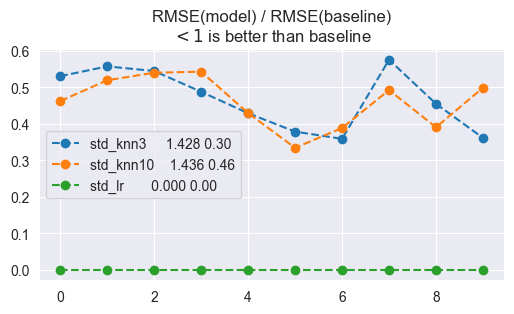

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))

baseline_results = skms.cross_val_score(
    regressors['baseline'],
    student_ftrs, student_tgt,
    scoring=msrs['RMSE'], cv=10
)

for mod_name, model in regressors.items():
    if mod_name.startswith("std_"):
        cv_results = skms.cross_val_score(
            model,
            student_ftrs, student_tgt,
            scoring=msrs['RMSE'], cv=10
        )
        my_lbl = "{:12s} {:.3f} {:.2f}".format(
            mod_name, cv_results.mean(), cv_results.std())
        ax.plot(cv_results / baseline_results, 'o--', label=my_lbl)

ax.set_title("RMSE(model) / RMSE(baseline)\n$<1$ is better than baseline")
ax.legend()


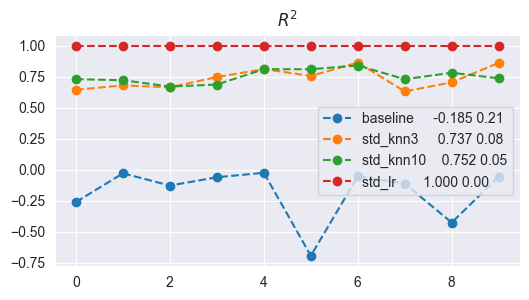

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))

for mod_name, model in regressors.items():
    cv_results = skms.cross_val_score(
        model,
        student_ftrs, student_tgt,
        cv=10
    )
    my_lbl = "{:12s} {:.3f} {:.2f}".format(
        mod_name, cv_results.mean(), cv_results.std())
    ax.plot(cv_results, 'o--', label=my_lbl)

ax.set_title("$R^2$")
ax.legend()  # uncomment for summary stats


In [35]:
msrs = {
    'MAD': metrics.mean_absolute_error,
    'RMSE': rms_error
}

results = {}

for mod_name, model in regressors.items():
    cv_preds = skms.cross_val_predict(
        model,
        student_ftrs, student_tgt,
        cv=10
    )
    for ax, msr in zip(axes, msrs):
        msr_results = msrs[msr](student_tgt, cv_preds)
        results.setdefault(msr, []).append(msr_results)

df = pd.DataFrame(results, index=regressors.keys())
df


,MAD,RMSE
baseline,2.4475,3.2717
std_knn3,1.0354,1.4583
std_knn10,1.0348,1.5052
std_lr,0.0000,0.0000


,count,mean,std,min,25%,50%,75%,max
G3,649.0000,11.9060,3.2307,0.0000,10.0000,12.0000,14.0000,19.0000


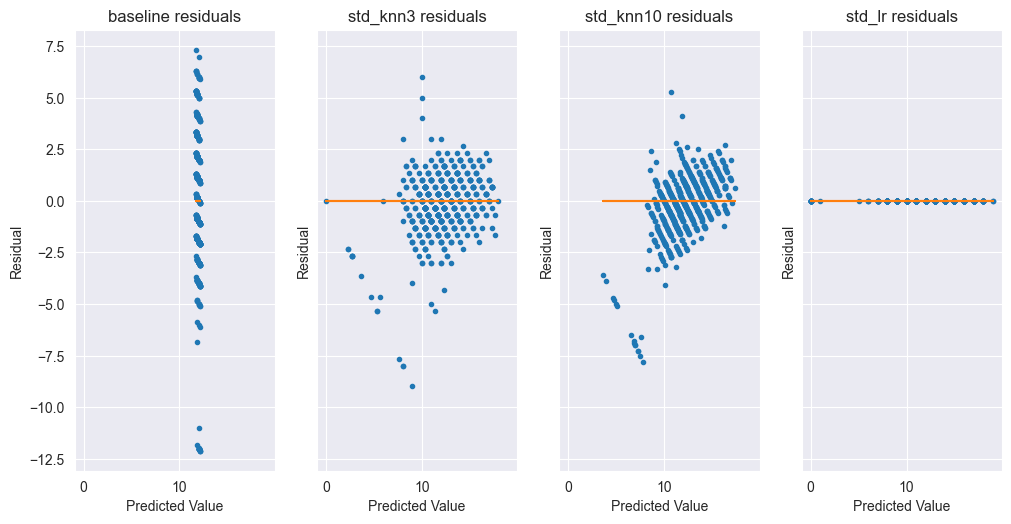

In [37]:
fig, axes = plt.subplots(1, 4, figsize=(10, 5), sharex=True, sharey=True)
fig.tight_layout()

for model_name, ax in zip(regressors, axes):
    model = regressors[model_name]
    preds = skms.cross_val_predict(model, student_ftrs, student_tgt, cv=10)
    regression_residuals(ax, preds, student_tgt)
    ax.set_title(model_name + " residuals")

pd.DataFrame(student_tgt).describe().T
